# Title: LLM RAG Optimization
## Subtitle: RAG Agent Optimization with Distilation and Supervised Fine Tuning
Author: Tommy Poole, Spring Semester 2026, University of San Diego, Shirley Marcos School of Engineering, Master's in Science of Applied Artificial Intelligence

**Attribution:** Claude code March 29. Perplexity March 29.





---



## Introduction

RAG

This project is defined to compare two rietreval augmented generation agents both powered by the same model. Both agents have access to the same data for reference, but one of them has been fine-tuned with supervised fine tuning on a curated set of question answer pairs. The code is outlined as follows:

1. Import key libraries.
2. Download models for project from HuggingFace (Qwen3-Next-80B-Thinking for reasoning tasks), Connect to (Calude 4.6) for Evaluation via API,  download from Hugging Face (SmolLM3-3B ) as the nano model we'll fine tune and compare.
3. Ingest a corpus of data.
4. Generate text embeddings and store in vector store.
5. Use a reasoning model to create 200 question answer pairs based on the data converted to JSONL format.
6. Evaluate questions created using Anthropic.
7. Fine tune a mini or nano model with the question answer pairs.
8. Test 50 questions against the fine tuned model, and a non fine tuned model, both with the same prompt and corpus for reitreival.
9. Use a different reasononing model to evaluate each response against the ground truth for groundedness, relevance, and correctness. Use Microsoft documentation to determine scales to match their CoPilot studio evaluation metrics.
10.Generate responses to the 50 questions using Claude as well, and score against same metrics and evaluate.
11. Discussion of results.

# 1. Import Libraries

**NOTE:** If using Google CoLab, connect to GPU with High Ram.

In [1]:
# Install dependencies (run once)
!pip install transformers datasets huggingface_hub peft trl accelerate bitsandbytes
!pip install sentence-transformers faiss-cpu
!pip install anthropic
!pip install jsonlines tqdm
!pip install pypdf
!pip install matplotlib seaborn
!pip install -q -U google-generativeai
!pip install pdfplumber pymupdf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 531.0/531.0 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 35.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 99.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 469.4/469.4 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 333.7/333.7 kB 7.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.1/68.1 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 86.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.9/24.9 MB 110.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 149.7 MB/s eta 0:00:00


In [2]:
# Standard Library
import os
import json
import re
from pathlib import Path
import sklearn
from sklearn.model_selection import train_test_split
import pypdf
import random, time
from peft import PeftModel
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from math import pi
import pdfplumber
import fitz

# Third-party: data & numerics
import numpy as np
import pandas as pd
from tqdm import tqdm
import jsonlines

# PyTorch
import torch

# HuggingFace: models, tokenizers, datasets
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig,
    TrainingArguments,
    pipeline,
)
from datasets import Dataset, load_dataset
from huggingface_hub import login as hf_login

# HuggingFace: fine-tuning (PEFT / SFT)
from peft import LoraConfig, get_peft_model, TaskType
from trl import SFTTrainer, SFTConfig

# Embeddings & vector store
from sentence_transformers import SentenceTransformer
import faiss

# Anthropic (Claude)
import anthropic

# Gemini
import google.generativeai as genai

# Sanity check (print for check)
print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")
print(f"Device          : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")


PyTorch version : 2.10.0+cu128
CUDA available  : True
Device          : NVIDIA RTX PRO 6000 Blackwell Server Edition


/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


# 2. Model Setup & API Connections

In [11]:
# API Keys
from google.colab import userdata

# In Colab: Secrets panel add HF_TOKEN and ANTHROPIC_API_KEY and GEMINI_KEY
HF_TOKEN        = userdata.get("HF_TOKEN")
ANTHROPIC_KEY   = userdata.get("ANTHROPIC_KEY")
GEMINI      = userdata.get("GEMINI")

# Gemini setup
genai.configure(api_key=GEMINI)

# Gemini Generate content
GEMINI_MODEL = genai.GenerativeModel('gemini-2.5-flash')
response = GEMINI_MODEL.generate_content("Gemini says, Hello, world!")
print(response.text)

# HF setup
hf_login(token=HF_TOKEN)
print("")
print("---")
print("")
print("HuggingFace login successful.")

# Anthropic client (Claude sonnet-4-6 for evaluation)
claude_client = anthropic.Anthropic(api_key=ANTHROPIC_KEY)
CLAUDE_MODEL  = "claude-sonnet-4-6"

# Quick connectivity check
_ping = claude_client.messages.create(
    model=CLAUDE_MODEL,
    max_tokens=16,
    messages=[{"role": "user", "content": "Reply OK"}],
)
print("")
print("---")
print("")
print(f"Claude connected  : {_ping.content[0].text.strip()}")
print("")
print("---")
print("")

# Qwen3 reasoning model (4-bit quantized — requires ~40 GB VRAM)
#REASONING_MODEL_ID = "Qwen/Qwen3-Next-80B-A3B-Thinking"
REASONING_MODEL_ID = "Qwen/Qwen3-8B" #start with smaller reasoning model to get code working

bnb_4bit = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)

print(f"Loading reasoning model: {REASONING_MODEL_ID} ...")
reasoning_tokenizer = AutoTokenizer.from_pretrained(REASONING_MODEL_ID, token=HF_TOKEN)
reasoning_model = AutoModelForCausalLM.from_pretrained(
    REASONING_MODEL_ID,
    quantization_config=bnb_4bit,
    device_map="auto",
    trust_remote_code=True,  # Qwen needs this
    token=HF_TOKEN,
)
reasoning_model.eval()
print("✅ Reasoning model loaded")

# SmolLM3-3B base model (fine-tune target)
SMOL_MODEL_ID = "HuggingFaceTB/SmolLM3-3B"

print(f"Loading base model: {SMOL_MODEL_ID} ...")
smol_tokenizer = AutoTokenizer.from_pretrained(SMOL_MODEL_ID, token=HF_TOKEN)
smol_tokenizer.pad_token = smol_tokenizer.eos_token   # required for SFT batching

smol_model_base = AutoModelForCausalLM.from_pretrained(
    SMOL_MODEL_ID,
    torch_dtype=torch.bfloat16,
    device_map="auto",
    token=HF_TOKEN,
)
smol_model_base.eval()
print("SmolLM3-3B base model loaded.")
print("\nAll models ready.")


Indeed! "Hello, world!" is the classic first program message, a perfect way for any new system (or AI!) to make its debut.

As a large language model from Google, I understand the sentiment! How can I help you today after Gemini's grand entrance?

---

HuggingFace login successful.

---

Claude connected  : OK

---

Loading reasoning model: Qwen/Qwen3-8B ...


Loading weights:   0%|          | 0/399 [00:00<?, ?it/s]

✅ Reasoning model loaded
Loading base model: HuggingFaceTB/SmolLM3-3B ...


Loading weights:   0%|          | 0/326 [00:00<?, ?it/s]

SmolLM3-3B base model loaded.

All models ready.


# 3. Corpus Ingestion

In [8]:
# Config
DATASET_DIR  = Path("data")          # add more PDFs here to expand the corpus
CHUNK_SIZE   = 512                   # characters per chunk
CHUNK_OVERLAP = 64                   # overlap to preserve context across chunks

# Helpers
# Extract data from PDF to one single string
def extract_text_from_pdf(pdf_path: Path) -> str:
    """Return all text from a PDF as a single string (robust multi-backend)."""

    # pdfplumber (best for text/tables)
    try:
        with pdfplumber.open(str(pdf_path)) as pdf:
            pages = [page.extract_text() or "" for page in pdf.pages[:20]]  # Limit pages
            text = "\n".join(pages)
            if text.strip():
                return text
    except Exception as e:
        print(f"  pdfplumber failed: {e}")

    # PyMuPDF (fastest, handles corrupt)
    try:
        doc = fitz.open(str(pdf_path))
        text = ""
        for page in doc[:20]:
            text += page.get_text()
        doc.close()
        if text.strip():
            return text
    except Exception as e:
        print(f"  PyMuPDF failed: {e}")

    # Fallback message
    return f"[EXTRACTION FAILED: {pdf_path.name}]"

# Semantic chunking for optimized performance
def chunk_text(text: str, chunk_size: int = CHUNK_SIZE, overlap: int = CHUNK_OVERLAP) -> list[str]:
    """Split by paragraphs/headings first, then character chunks."""

    # Split into paragraphs/sections (semantic boundaries)
    paragraphs = re.split(r'\n\s*\n|\n#{1,3}\s', text)  # Double newline or headings

    # Chunk long paragraphs
    chunks = []
    for para in paragraphs:
        para = para.strip()
        if not para:
            continue

        # If para fits, keep whole
        if len(para) <= chunk_size:
            chunks.append(para)
        else:
            # Character chunk with overlap
            start = 0
            while start < len(para):
                end = start + chunk_size
                chunk = para[start:end].strip()
                if chunk:
                    chunks.append(chunk)
                start += chunk_size - overlap

    # Remove tiny/empty
    return [c for c in chunks if len(c) > 50]

# Ingest all PDFs in DATASET_DIR
pdf_files = sorted(DATASET_DIR.glob("*.pdf"))
assert pdf_files, f"No PDFs found in {DATASET_DIR.resolve()}"

corpus_chunks = []   # list of dicts: {source, chunk_id, text}

for pdf_path in pdf_files:
    raw_text = extract_text_from_pdf(pdf_path)
    chunks   = chunk_text(raw_text)
    for i, chunk in enumerate(chunks):
        corpus_chunks.append({
            "source"   : pdf_path.name,
            "chunk_id" : i,
            "text"     : chunk,
        })
    print(f"  {pdf_path.name}: {len(raw_text):,} chars → {len(chunks):,} chunks")

# Token count - Uses smol_tokenizer; swap for any tokenizer to measure against a different model
all_text      = " ".join(c["text"] for c in corpus_chunks)
token_ids     = smol_tokenizer(all_text, add_special_tokens=False)["input_ids"]
total_tokens  = len(token_ids)

# Confirm chunks from PDF- print 5 random chunk samples
import random
samples = random.sample(corpus_chunks, min(5, len(corpus_chunks)))

print("\n=== 5 RANDOM CHUNK SAMPLES ===")
for i, chunk in enumerate(samples, 1):
    print(f"\n{i}. {chunk['source']} (chunk {chunk['chunk_id']})")
    print(f"   {repr(chunk['text'][:200])}...")  # First 200 chars + repr for quotes


#Pring Info
print("")
print("---")
print("")
print(f"\nCorpus summary")
print(f"  PDFs loaded   : {len(pdf_files)}")
print(f"  Total chunks  : {len(corpus_chunks):,}")
print(f"  Total chars   : {len(all_text):,}")
print(f"  Total tokens  : {total_tokens:,}  (via {SMOL_MODEL_ID} tokenizer)")


  azure-foundry.pdf: 22,974 chars → 57 chunks

=== 5 RANDOM CHUNK SAMPLES ===

1. azure-foundry.pdf (chunk 36)
   '\uea80 Tip\nCode uses Azure AI Projects 2.x and is incompatible with Azure AI Projects 1.x. See the\nFoundry (classic) documentation for the Azure AI Projects 1.x version.\nCreate an agent\nCreate an agent usi'...

2. azure-foundry.pdf (chunk 4)
   'ndpoints ai-generative, azure-ai-ml, AzureOpenAI()) projects 2.x) + OpenAI() against one\nagainst 5+ endpoints project endpoint.\nTerminology Threads, Messages, Runs, Assistants Conversations, Items, Re'...

3. azure-foundry.pdf (chunk 0)
   'Tell us about your PDF experience.\nWhat is Microsoft Foundry?\nMicrosoft Foundry is a unified Azure platform-as-a-service offering for enterprise AI\noperations, model builders, and application developm'...

4. azure-foundry.pdf (chunk 18)
   'ss control for Microsoft\nFoundry.\nA list of user email addresses or Microsoft Entra security group IDs for team members\nwho need access.\nSelect

- 26,281 characters, 5,657 tokens
- 57 chunks, 25,866 chars, 5,568 tokens

# 4. Embeddings & Vector Store

In [9]:
# Config
EMBED_MODEL_ID = "all-MiniLM-L6-v2"   # fast, reliable; can swap for larger model if needed
TOP_K          = 5                     # default chunks to retrieve per query

# Load embedding model
print(f"Loading embedding model: {EMBED_MODEL_ID} ...")
embed_model = SentenceTransformer(EMBED_MODEL_ID)
EMBED_DIM   = embed_model.get_sentence_embedding_dimension()
print(f"Embedding dimension: {EMBED_DIM}")

# Encode corpus chunks
print(f"Encoding {len(corpus_chunks):,} chunks ...")
chunk_texts = [c["text"] for c in corpus_chunks]

chunk_embeddings = embed_model.encode(
    chunk_texts,
    batch_size=64,
    show_progress_bar=True,
    normalize_embeddings=True,   # required for cosine similarity via inner product
    convert_to_numpy=True,
)

# Build FAISS index (cosine similarity via inner product on normalized vecs)
faiss_index = faiss.IndexFlatIP(EMBED_DIM)
faiss_index.add(chunk_embeddings)
print(f"FAISS index built: {faiss_index.ntotal:,} vectors")

# Retrieval helper
def retrieve(query: str, k: int = TOP_K) -> list[dict]:
    """Return the top-k most relevant corpus chunks for a given query."""
    query_vec = embed_model.encode(
        [query],
        normalize_embeddings=True,
        convert_to_numpy=True,
    )
    scores, indices = faiss_index.search(query_vec, k)
    results = []
    for score, idx in zip(scores[0], indices[0]):
        results.append({**corpus_chunks[idx], "score": float(score)})
    return results

# Smoke test
test_query   = "What is Azure AI Foundry?"
test_results = retrieve(test_query)

print(f"\nSmoke test — query: '{test_query}'")
for r in test_results:
    print(f"  [{r['score']:.3f}] {r['source']} chunk {r['chunk_id']}: {r['text'][:80]}...")


Loading embedding model: all-MiniLM-L6-v2 ...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embedding dimension: 384
Encoding 57 chunks ...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

FAISS index built: 57 vectors

Smoke test — query: 'What is Azure AI Foundry?'
  [0.807] azure-foundry.pdf chunk 2: I keys, and existing state.
Using hub-based projects? Hub-based projects are acc...
  [0.732] azure-foundry.pdf chunk 4: ndpoints ai-generative, azure-ai-ml, AzureOpenAI()) projects 2.x) + OpenAI() aga...
  [0.730] azure-foundry.pdf chunk 3: Foundry Microsoft Foundry
Brand Azure AI Services Foundry Tools
Portal Foundry (...
  [0.709] azure-foundry.pdf chunk 0: Tell us about your PDF experience.
What is Microsoft Foundry?
Microsoft Foundry ...
  [0.676] azure-foundry.pdf chunk 7: el tracking.
Centralized AI asset management – Manage all agents, models, and to...


# 5. QA Pair Generation & Evaluation

In [25]:
# Config
NUM_QA_PAIRS    = 200
QA_OUTPUT_FILE  = Path("data/qa_pairs.jsonl")
MAX_NEW_TOKENS  = 512
TEMPERATURE     = 0.7
SEED            = 42

random.seed(SEED)

# Prompt template
QA_PROMPT = """\
Generate EXACTLY ONE question-answer pair as JSON. No explanations.

MANDATORY FORMAT — copy exactly:
{{"question": "Your question?", "answer": "Your answer from passage only"}}

PASSAGE: {passage}
"""

# Reduce failed extractions
def extract_json(text: str) -> dict | None:
    """Extract first valid JSON even if malformed."""
    patterns = [
        r'\{.*?"question".*?"answer".*?\}',  # Your original + extras
        r'\{[^{}]*"q[^}]*"a[^}]*\}',        # Short form
        r'\{.*\}',                          # Any JSON
    ]

    for pattern in patterns:
        matches = re.findall(pattern, text, re.DOTALL)
        for match_str in matches:
            try:
                parsed = json.loads(match_str)
                if isinstance(parsed, dict) and "question" in parsed and "answer" in parsed:
                    return parsed
            except json.JSONDecodeError:
                continue
    return None

# Inference helper
# Batched QA generation
def generate_qa_batch(passages: list[str], batch_size: int = 16) -> list[dict]:
    """Batch-generate QA pairs."""
    qa_pairs = []

    for i in tqdm(range(0, len(passages), batch_size), desc="QA batches"):
        batch = passages[i:i+batch_size]
        prompts = [QA_PROMPT.format(passage=p.strip()) for p in batch]

        inputs = reasoning_tokenizer(
            prompts, return_tensors="pt", padding=True, truncation=True
        ).to(reasoning_model.device)

        with torch.no_grad():
            outputs = reasoning_model.generate(
                **inputs,
                max_new_tokens=MAX_NEW_TOKENS,
                temperature=TEMPERATURE,
                do_sample=True,
                pad_token_id=reasoning_tokenizer.eos_token_id,
            )

        # Decode & extract JSON
        for j, (prompt, output) in enumerate(zip(prompts, outputs)):
            new_ids = output[inputs["input_ids"][j].shape[-1]:]
            raw = reasoning_tokenizer.decode(new_ids, skip_special_tokens=True).strip()

            # Robust JSON extraction
            qa = extract_json(raw)
            if qa and qa.get("question") and qa.get("answer"):
                qa_pairs.append({
                    "id": len(qa_pairs),
                    "question": qa["question"].strip(),
                    "answer": qa["answer"].strip(),
                    "source": sampled[i+j]["source"],
                    "chunk_id": sampled[i+j]["chunk_id"],
                    "source_text": sampled[i+j]["text"],
                })

    return qa_pairs

# Generate
qa_pairs = generate_qa_batch([c["text"] for c in sampled])

# Save to JSONL
QA_OUTPUT_FILE.parent.mkdir(exist_ok=True)
with jsonlines.open(QA_OUTPUT_FILE, mode="w") as writer:
    writer.write_all(qa_pairs)
print(f"Saved to  : {QA_OUTPUT_FILE}")

# Preview
print("\nSample QA pairs:")
for pair in qa_pairs[:3]:
    print(f"\n  Q: {pair['question']}")
    print(f"  A: {pair['answer']}")
    print(f"  Source: {pair['source']} chunk {pair['chunk_id']}")

# Print number of QA Pairs
print(f"\nTotal QA pairs: {len(qa_pairs)}")

QA batches: 100%|██████████| 13/13 [03:42<00:00, 17.09s/it]

Saved to  : data/qa_pairs.jsonl

Sample QA pairs:

  Q: What is PDF?
  A: PDF, or Portable Document Format, is a file format developed by Adobe for the representation of documents in a manner independent of application software, computer hardware, and operating systems.
  Source: azure-foundry.pdf chunk 0

  Q: What is the main purpose of Foundry as a service?
  A: provides a unified platform for deploying and managing LLMs, with built-in support for Azure Active Directory, Azure Monitor, and Azure DevOps
  Source: azure-foundry.pdf chunk 1

  Q: What is the current brand name for Azure AI Studio and Azure AI Foundry?
  A: Microsoft Foundry
  Source: azure-foundry.pdf chunk 2

Total QA pairs: 157


# 6. Supervised Fine-Tuning (LoRA + SFT)

In [27]:
# Config
FT_OUTPUT_DIR    = Path("models/smollm3-3b-finetuned")
FT_LOGGING_DIR   = Path("models/logs")
TRAIN_SPLIT      = 0.9      # 90% train, 10% validation

# LoRA hyperparameters
LORA_R           = 16
LORA_ALPHA       = 32
LORA_DROPOUT     = 0.05
LORA_TARGET_MODS = ["q_proj", "k_proj", "v_proj", "o_proj",
                    "gate_proj", "up_proj", "down_proj"]

# Training hyperparameters
NUM_EPOCHS       = 3
BATCH_SIZE       = 4
GRAD_ACCUM       = 4        # effective batch = BATCH_SIZE * GRAD_ACCUM = 16
LEARNING_RATE    = 2e-4
MAX_SEQ_LEN      = 512

# Format QA pairs as chat messages
def format_chat(pair: dict) -> str:
    """Apply the model's chat template to a QA pair."""
    messages = [
        {"role": "user",      "content": pair["question"]},
        {"role": "assistant", "content": pair["answer"]},
    ]
    return smol_tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=False,
    )

formatted_texts = [format_chat(p) for p in qa_pairs]

# Train / validation split
train_texts, val_texts = train_test_split(
    formatted_texts, train_size=TRAIN_SPLIT, random_state=SEED
)
train_dataset = Dataset.from_dict({"text": train_texts})
val_dataset   = Dataset.from_dict({"text": val_texts})

print(f"Train samples : {len(train_dataset)}")
print(f"Val samples   : {len(val_dataset)}")
print(f"\nSample formatted input:\n{train_texts[0][:300]}...")

# LoRA config
lora_config = LoraConfig(
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,
    target_modules=LORA_TARGET_MODS,
    task_type=TaskType.CAUSAL_LM,
    bias="none",
)

smol_model_ft = get_peft_model(smol_model_base, lora_config)
smol_model_ft.print_trainable_parameters()

# SFT training config
sft_config = SFTConfig(
    output_dir=str(FT_OUTPUT_DIR),
    logging_dir=str(FT_LOGGING_DIR),
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=GRAD_ACCUM,
    learning_rate=LEARNING_RATE,
    lr_scheduler_type="cosine",
    warmup_ratio=0.05,
    bf16=True,
    max_length=MAX_SEQ_LEN,
    dataset_text_field="text",
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    logging_steps=10,
    report_to="none",
)

# Train
trainer = SFTTrainer(
    model=smol_model_ft,
    args=sft_config,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    processing_class=smol_tokenizer,
)

print("\nStarting fine-tuning ...")
train_result = trainer.train()

print(f"\nTraining complete.")
print(f"  Train loss        : {train_result.training_loss:.4f}")
print(f"  Train runtime (s) : {train_result.metrics['train_runtime']:.1f}")

# Save fine-tuned model & tokenizer
FT_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
trainer.save_model(str(FT_OUTPUT_DIR))
smol_tokenizer.save_pretrained(str(FT_OUTPUT_DIR))
print(f"  Model saved to    : {FT_OUTPUT_DIR}")


/usr/local/lib/python3.12/dist-packages/peft/mapping_func.py:72: UserWarning: You are trying to modify a model with PEFT for a second time. If you want to reload the model with a different config, make sure to call `.unload()` before.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:285: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Train samples : 141
Val samples   : 16

Sample formatted input:
<|im_start|>system
## Metadata

Knowledge Cutoff Date: June 2025
Today Date: 30 March 2026
Reasoning Mode: /think

## Custom Instructions

You are a helpful AI assistant named SmolLM, trained by Hugging Face. Your role as an assistant involves thoroughly exploring questions through a systematic thin...
trainable params: 30,228,480 || all params: 3,105,327,104 || trainable%: 0.9734


Adding EOS to train dataset:   0%|          | 0/141 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/141 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/141 [00:00<?, ? examples/s]

...

Truncating eval dataset:   0%|          | 0/16 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 128012}.



Starting fine-tuning ...


Epoch,Training Loss,Validation Loss
1,No log,0.356259
2,0.652609,0.261419
3,0.309475,0.246615



Training complete.
  Train loss        : 0.4254
  Train runtime (s) : 25.0
  Model saved to    : models/smollm3-3b-finetuned


# 7. RAG Inference - Base v. Fine-Tuned

In [28]:
# Config
NUM_TEST         = 50
TEST_OUTPUT_FILE = Path("data/test_results.jsonl")
RAG_MAX_TOKENS   = 256
RAG_TEMPERATURE  = 0.3    # lower = more deterministic for evaluation

RAG_PROMPT = """\
You are a helpful assistant. Answer the question using ONLY the context provided.
If the context does not contain enough information, say so.

Context:
{context}

Question: {question}
Answer:"""

# Derive 50 held-out test pairs (same seed → reproducible split)
_, test_pairs = train_test_split(qa_pairs, train_size=TRAIN_SPLIT, random_state=SEED)
if len(test_pairs) < NUM_TEST:
    # If val set is smaller than 50, supplement with unseen random sample
    train_ids = {id(p) for p in _}
    extras    = [p for p in qa_pairs if id(p) not in train_ids]
    test_pairs = (test_pairs + extras)[:NUM_TEST]
else:
    test_pairs = test_pairs[:NUM_TEST]

print(f"Test set size: {len(test_pairs)} questions")

# Load fine-tuned model for inference
print(f"\nLoading fine-tuned model from {FT_OUTPUT_DIR} ...")
ft_tokenizer = AutoTokenizer.from_pretrained(str(FT_OUTPUT_DIR))
ft_base      = AutoModelForCausalLM.from_pretrained(
    SMOL_MODEL_ID,
    torch_dtype=torch.bfloat16,
    device_map="auto",
    token=HF_TOKEN,
)
smol_model_finetuned = PeftModel.from_pretrained(ft_base, str(FT_OUTPUT_DIR))
smol_model_finetuned.eval()
print("Fine-tuned model ready.")

# RAG inference helper
def rag_answer(question: str, model, tokenizer, k: int = TOP_K) -> tuple[str, list[dict]]:
    """Retrieve context, build prompt, generate answer. Returns (answer, retrieved_chunks)."""
    chunks  = retrieve(question, k=k)
    context = "\n\n".join(c["text"] for c in chunks)
    prompt  = RAG_PROMPT.format(context=context, question=question)

    inputs  = tokenizer(prompt, return_tensors="pt", truncation=True,
                        max_length=1024).to(model.device)
    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=RAG_MAX_TOKENS,
            temperature=RAG_TEMPERATURE,
            do_sample=RAG_TEMPERATURE > 0,
            pad_token_id=tokenizer.eos_token_id,
        )
    new_ids = output_ids[0][inputs["input_ids"].shape[-1]:]
    answer  = tokenizer.decode(new_ids, skip_special_tokens=True).strip()
    return answer, chunks

# Run inference on both models
results = []

for pair in tqdm(test_pairs, desc="Running RAG inference"):
    q             = pair["question"]
    ground_truth  = pair["answer"]

    base_answer, base_chunks = rag_answer(q, smol_model_base, smol_tokenizer)
    ft_answer,   ft_chunks   = rag_answer(q, smol_model_finetuned, ft_tokenizer)

    results.append({
        "id"              : pair["id"],
        "question"        : q,
        "ground_truth"    : ground_truth,
        "source"          : pair["source"],
        "chunk_id"        : pair["chunk_id"],
        # Base model
        "base_answer"     : base_answer,
        "base_chunks"     : [c["chunk_id"] for c in base_chunks],
        # Fine-tuned model
        "ft_answer"       : ft_answer,
        "ft_chunks"       : [c["chunk_id"] for c in ft_chunks],
    })

# Save results
with jsonlines.open(TEST_OUTPUT_FILE, mode="w") as writer:
    writer.write_all(results)
print(f"\nResults saved to: {TEST_OUTPUT_FILE}")

# Preview
print("\nSample result:")
r = results[0]
print(f"  Q             : {r['question']}")
print(f"  Ground truth  : {r['ground_truth']}")
print(f"  Base answer   : {r['base_answer'][:120]}...")
print(f"  FT answer     : {r['ft_answer'][:120]}...")


Test set size: 32 questions

Loading fine-tuned model from models/smollm3-3b-finetuned ...


Loading weights:   0%|          | 0/326 [00:00<?, ?it/s]

Fine-tuned model ready.


Running RAG inference: 100%|██████████| 32/32 [01:07<00:00,  2.10s/it]


Results saved to: data/test_results.jsonl

Sample result:
  Q             : What is the main purpose of the Microsoft Foundry quickstart article?
  Ground truth  : Create a Microsoft Foundry project and deploy a model, and grant access to team members if managing a team.
  Base answer   : To create a Microsoft Foundry project and deploy a model....
  FT answer     : Create a Microsoft Foundry project and deploy a model....


# 8. Claude Evaluation - Groundedness, Relavance, Correctness


Metric definitions align with Microsoft Azure AI Foundry / Copilot Studio: https://learn.microsoft.com/en-us/azure/ai-foundry/concepts/evaluation-metrics-built-in

**Groundedness**  (1–5): Is the response supported by the retrieved context?
   - 1 = Ungrounded / contradicts context
   - 3 = Partially grounded, some unsupported claims
   - 5 = Fully grounded, every claim traceable to context

**Relevance**     (1–5): Does the response directly address the question?
   - 1 = Off-topic or unrelated
   - 3 = Partially addresses the question
   - 5 = Completely and precisely answers the question

 **Correctness**   (1–5): Does the response match the ground-truth answer?
   - 1 = Factually wrong or contradicts ground truth
   - 3 = Partially correct, missing key facts
   - 5 = Fully correct, consistent with ground truth

In [29]:
# Config
EVAL_OUTPUT_FILE = Path("data/eval_results.jsonl")

EVAL_PROMPT = """\
You are an expert evaluator for AI-generated responses, following Microsoft Azure \
AI Foundry evaluation standards.

Score the RESPONSE on three dimensions (each 1–5):

groundedness: Is every claim in the response supported by the CONTEXT?
  1=Ungrounded  2=Mostly unsupported  3=Partially grounded  \
4=Mostly grounded  5=Fully grounded

relevance: Does the response directly and completely address the QUESTION?
  1=Off-topic  2=Tangentially related  3=Partially addresses  \
4=Mostly relevant  5=Fully relevant

correctness: How well does the response match the GROUND TRUTH answer?
  1=Contradicts  2=Mostly wrong  3=Partially correct  \
4=Mostly correct  5=Fully correct

Respond in valid JSON only:
{{"groundedness": <1-5>, "relevance": <1-5>, "correctness": <1-5>, \
"reason": "<one concise sentence>"}}

CONTEXT:
{context}

QUESTION:
{question}

GROUND TRUTH:
{ground_truth}

RESPONSE:
{response}
"""

# Evaluation helper
def evaluate_response(question: str, ground_truth: str,
                      response: str, context: str) -> dict:
    """Score a single response with Claude. Returns score dict."""
    prompt = EVAL_PROMPT.format(
        context=context[:1500],   # cap context length for token efficiency
        question=question,
        ground_truth=ground_truth,
        response=response,
    )
    msg = claude_client.messages.create(
        model=CLAUDE_MODEL,
        max_tokens=128,
        messages=[{"role": "user", "content": prompt}],
    )
    raw   = msg.content[0].text.strip()
    match = re.search(
        r'\{.*?"groundedness".*?"relevance".*?"correctness".*?\}', raw, re.DOTALL
    )
    if match:
        try:
            return json.loads(match.group())
        except json.JSONDecodeError:
            pass
    return {"groundedness": None, "relevance": None,
            "correctness": None, "reason": raw}

# Retrieve context string for each result (consistent for both models)
def get_context_str(question: str, k: int = TOP_K) -> str:
    return "\n\n".join(c["text"] for c in retrieve(question, k=k))

# Evaluate base and fine-tuned answers for all 50 questions
eval_results = []

for r in tqdm(results, desc="Evaluating with Claude"):
    context = get_context_str(r["question"])

    base_scores = evaluate_response(
        r["question"], r["ground_truth"], r["base_answer"], context
    )
    ft_scores = evaluate_response(
        r["question"], r["ground_truth"], r["ft_answer"], context
    )
    time.sleep(0.15)   # rate-limit buffer

    eval_results.append({
        **r,
        "base_groundedness" : base_scores.get("groundedness"),
        "base_relevance"    : base_scores.get("relevance"),
        "base_correctness"  : base_scores.get("correctness"),
        "base_reason"       : base_scores.get("reason"),
        "ft_groundedness"   : ft_scores.get("groundedness"),
        "ft_relevance"      : ft_scores.get("relevance"),
        "ft_correctness"    : ft_scores.get("correctness"),
        "ft_reason"         : ft_scores.get("reason"),
    })

# Save
with jsonlines.open(EVAL_OUTPUT_FILE, mode="w") as writer:
    writer.write_all(eval_results)
print(f"Evaluation results saved to: {EVAL_OUTPUT_FILE}")

# Aggregate scores
df = pd.DataFrame(eval_results)

metrics   = ["groundedness", "relevance", "correctness"]
models    = {"Base SmolLM3-3B": "base", "Fine-Tuned SmolLM3-3B": "ft"}
summary   = {}

for label, prefix in models.items():
    summary[label] = {
        m: df[f"{prefix}_{m}"].dropna().astype(float).mean()
        for m in metrics
    }

summary_df = pd.DataFrame(summary).T
summary_df["avg_overall"] = summary_df[metrics].mean(axis=1)

print("\n── Evaluation Summary (1–5 scale, Microsoft Azure AI Foundry metrics) ──")
print(summary_df.round(3).to_string())


Evaluating with Claude: 100%|██████████| 32/32 [02:53<00:00,  5.43s/it]

Evaluation results saved to: data/eval_results.jsonl

── Evaluation Summary (1–5 scale, Microsoft Azure AI Foundry metrics) ──
                       groundedness  relevance  correctness  avg_overall
Base SmolLM3-3B               3.938      3.656        3.500        3.698
Fine-Tuned SmolLM3-3B         3.688      3.750        3.406        3.615


# 9. Claude RAG Responses

In [34]:
# CONFIG
import google.generativeai as genai

GEMINI_MODEL = genai.GenerativeModel('gemini-2.5-flash')

GEMINI_RESULTS_FILE = Path("data/eval_results_with_gemini.jsonl")

GEMINI_RAG_PROMPT = """\
You are a helpful assistant. Answer the question using ONLY the context provided.
If the context does not contain enough information, say so.

Context:
{context}

Question: {question}
Answer:"""

# Gemini RAG inference helper
def gemini_rag_answer(question: str, k: int = TOP_K) -> tuple[str, str]:
    chunks = retrieve(question, k=k)
    context = "\n\n".join(c["text"] for c in chunks)
    prompt = GEMINI_RAG_PROMPT.format(context=context, question=question)

    response = GEMINI_MODEL.generate_content(  # No client.models!
        prompt,
        generation_config=genai.types.GenerationConfig(
            max_output_tokens=RAG_MAX_TOKENS,
            temperature=0.1,
        )
    )
    return response.text.strip(), context

# Generate Gemini answers + evaluate all three models
full_results = []

for r in tqdm(eval_results, desc="Gemini inference + evaluation"):
    # Gemini answer
    gemini_answer, context = gemini_rag_answer(r["question"])
    time.sleep(0.1)

    # Evaluate Gemini's answer with the same rubric
    gemini_scores = evaluate_response(
        r["question"], r["ground_truth"], gemini_answer, context
    )
    time.sleep(0.15)

    full_results.append({
        **r,
        "gemini_answer"        : gemini_answer,
        "gemini_groundedness"  : gemini_scores.get("groundedness"),
        "gemini_relevance"     : gemini_scores.get("relevance"),
        "gemini_correctness"   : gemini_scores.get("correctness"),
        "gemini_reason"        : gemini_scores.get("reason"),
    })

# Save
with jsonlines.open(GEMINI_RESULTS_FILE, mode="w") as writer:
    writer.write_all(full_results)
print(f"Full results saved to: {GEMINI_RESULTS_FILE}")

# Three-way summary table (updated for Gemini)
df_full = pd.DataFrame(full_results)

metrics = ["groundedness", "relevance", "correctness"]
all_models = {
    "Base SmolLM3-3B": "base",
    "Fine-Tuned SmolLM3-3B": "ft",
    f"Gemini ({GEMINI_MODEL})": "gemini",  # Updated
}
full_summary = {}

for label, prefix in all_models.items():
    full_summary[label] = {
        m: df_full[f"{prefix}_{m}"].dropna().astype(float).mean()
        for m in metrics
    }

full_summary_df = pd.DataFrame(full_summary).T
full_summary_df["avg_overall"] = full_summary_df[metrics].mean(axis=1)
full_summary_df = full_summary_df.sort_values("avg_overall", ascending=False)

print("\n── Three-Way Evaluation Summary (1–5, Microsoft Azure AI Foundry metrics) ──")
print(full_summary_df.round(3).to_string())

# Per-metric delta: FT vs Base
print("\n── Fine-Tuning Delta (FT − Base) ────────────────────────────────────────")
for m in metrics + ["avg_overall"]:
    delta = full_summary_df.loc["Fine-Tuned SmolLM3-3B", m] - \
            full_summary_df.loc["Base SmolLM3-3B", m]
    direction = "▲" if delta > 0 else ("▼" if delta < 0 else "─")
    print(f"  {m:<16}: {direction} {delta:+.3f}")

Gemini inference + evaluation:  22%|██▏       | 7/32 [00:30<01:48,  4.36s/it]WARNING:tornado.access:429 POST /v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 351.80ms



TooManyRequests: 429 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint: You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 5, model: gemini-2.5-flash
Please retry in 26.400311824s.

In [35]:
# CONFIG

CLAUDE_RESULTS_FILE = Path("data/eval_results_with_claude.jsonl")

CLAUDE_RAG_PROMPT = """\
You are a helpful assistant. Answer the question using ONLY the context provided.
If the context does not contain enough information, say so.

Context:
{context}

Question: {question}
Answer:"""

# Claude RAG inference helper
def claude_rag_answer(question: str, k: int = TOP_K) -> tuple[str, str]:
    """Retrieve context and generate an answer with Claude. Returns (answer, context)."""
    chunks  = retrieve(question, k=k)
    context = "\n\n".join(c["text"] for c in chunks)
    prompt  = CLAUDE_RAG_PROMPT.format(context=context, question=question)

    msg = claude_client.messages.create(
        model=CLAUDE_MODEL,
        max_tokens=RAG_MAX_TOKENS,
        messages=[{"role": "user", "content": prompt}],
    )
    return msg.content[0].text.strip(), context

# Generate Claude answers + evaluate all three models
full_results = []

for r in tqdm(eval_results, desc="Claude inference + evaluation"):
    # Claude answer
    claude_answer, context = claude_rag_answer(r["question"])
    time.sleep(0.1)

    # Evaluate Claude's answer with the same rubric
    claude_scores = evaluate_response(
        r["question"], r["ground_truth"], claude_answer, context
    )
    time.sleep(0.15)

    full_results.append({
        **r,
        "claude_answer"       : claude_answer,
        "claude_groundedness" : claude_scores.get("groundedness"),
        "claude_relevance"    : claude_scores.get("relevance"),
        "claude_correctness"  : claude_scores.get("correctness"),
        "claude_reason"       : claude_scores.get("reason"),
    })

# Save
with jsonlines.open(CLAUDE_RESULTS_FILE, mode="w") as writer:
    writer.write_all(full_results)
print(f"Full results saved to: {CLAUDE_RESULTS_FILE}")

# Three-way summary table
df_full = pd.DataFrame(full_results)

metrics     = ["groundedness", "relevance", "correctness"]
all_models  = {
    "Base SmolLM3-3B"       : "base",
    "Fine-Tuned SmolLM3-3B" : "ft",
    f"Claude ({CLAUDE_MODEL})" : "claude",
}
full_summary = {}

for label, prefix in all_models.items():
    full_summary[label] = {
        m: df_full[f"{prefix}_{m}"].dropna().astype(float).mean()
        for m in metrics
    }

full_summary_df = pd.DataFrame(full_summary).T
full_summary_df["avg_overall"] = full_summary_df[metrics].mean(axis=1)
full_summary_df = full_summary_df.sort_values("avg_overall", ascending=False)

print("\n── Three-Way Evaluation Summary (1–5, Microsoft Azure AI Foundry metrics) ──")
print(full_summary_df.round(3).to_string())

# Per-metric delta: FT vs Base
print("\n── Fine-Tuning Delta (FT − Base) ────────────────────────────────────────")
for m in metrics + ["avg_overall"]:
    delta = full_summary_df.loc["Fine-Tuned SmolLM3-3B", m] - \
            full_summary_df.loc["Base SmolLM3-3B", m]
    direction = "▲" if delta > 0 else ("▼" if delta < 0 else "─")
    print(f"  {m:<16}: {direction} {delta:+.3f}")


Claude inference + evaluation: 100%|██████████| 32/32 [02:53<00:00,  5.44s/it]

Full results saved to: data/eval_results_with_claude.jsonl

── Three-Way Evaluation Summary (1–5, Microsoft Azure AI Foundry metrics) ──
                            groundedness  relevance  correctness  avg_overall
Claude (claude-sonnet-4-6)         4.344      4.594        4.219        4.385
Base SmolLM3-3B                    3.938      3.656        3.500        3.698
Fine-Tuned SmolLM3-3B              3.688      3.750        3.406        3.615

── Fine-Tuning Delta (FT − Base) ────────────────────────────────────────
  groundedness    : ▼ -0.250
  relevance       : ▲ +0.094
  correctness     : ▼ -0.094
  avg_overall     : ▼ -0.083


#10. Visualization & Discussion

## Data Visualization

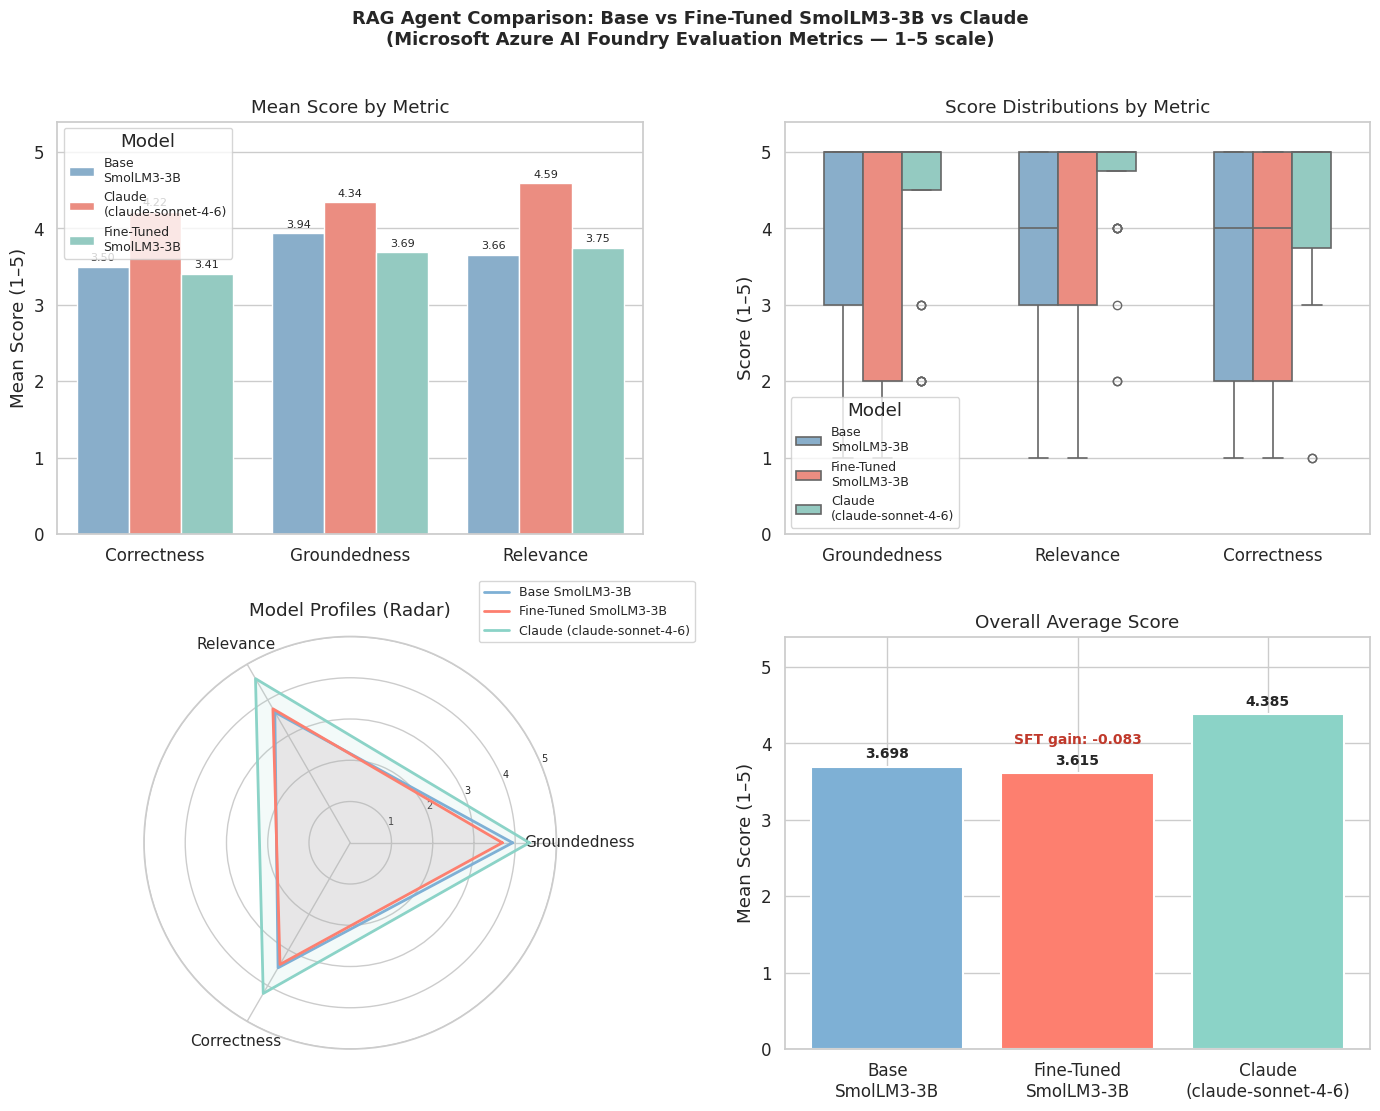

Figure saved to: figures/model_comparison.png


In [36]:
# Config
FIGURES_DIR = Path("figures")
FIGURES_DIR.mkdir(exist_ok=True)

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)

MODEL_LABELS = {
    "base"   : "Base\nSmolLM3-3B",
    "ft"     : "Fine-Tuned\nSmolLM3-3B",
    "claude" : f"Claude\n({CLAUDE_MODEL})",
}
MODEL_COLORS = {
    "base"   : "#7eb0d5",
    "ft"     : "#fd7f6f",
    "claude" : "#8bd3c7",
}
METRICS = ["groundedness", "relevance", "correctness"]

# Pre-compute long-form dataframe for seaborn
rows = []
for r in full_results:
    for prefix, label in MODEL_LABELS.items():
        for m in METRICS:
            val = r.get(f"{prefix}_{m}")
            if val is not None:
                rows.append({"model": label, "metric": m.capitalize(),
                             "score": float(val), "prefix": prefix})
df_long = pd.DataFrame(rows)

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle(
    "RAG Agent Comparison: Base vs Fine-Tuned SmolLM3-3B vs Claude\n"
    "(Microsoft Azure AI Foundry Evaluation Metrics — 1–5 scale)",
    fontsize=13, fontweight="bold", y=1.01,
)

# Plot 1: Grouped bar — mean scores per metric
ax1 = axes[0, 0]
mean_df = (
    df_long.groupby(["metric", "model"])["score"]
    .mean()
    .reset_index()
)
sns.barplot(
    data=mean_df, x="metric", y="score", hue="model",
    palette=list(MODEL_COLORS.values()), ax=ax1,
)
ax1.set_title("Mean Score by Metric")
ax1.set_xlabel("")
ax1.set_ylabel("Mean Score (1–5)")
ax1.set_ylim(0, 5.4)
ax1.yaxis.set_major_locator(mticker.MultipleLocator(1))
ax1.legend(title="Model", fontsize=9)
for bar in ax1.patches:
    h = bar.get_height()
    if h > 0:
        ax1.text(bar.get_x() + bar.get_width() / 2, h + 0.05,
                 f"{h:.2f}", ha="center", va="bottom", fontsize=8)

# Plot 2: Box plots — score distributions
ax2 = axes[0, 1]
sns.boxplot(
    data=df_long, x="metric", y="score", hue="model",
    palette=list(MODEL_COLORS.values()), ax=ax2,
    width=0.6, linewidth=1.2,
)
ax2.set_title("Score Distributions by Metric")
ax2.set_xlabel("")
ax2.set_ylabel("Score (1–5)")
ax2.set_ylim(0, 5.4)
ax2.yaxis.set_major_locator(mticker.MultipleLocator(1))
ax2.legend(title="Model", fontsize=9)

# Plot 3: Radar / spider chart — overall model profiles
ax3 = axes[1, 0]
ax3.remove()
ax3 = fig.add_subplot(2, 2, 3, polar=True)

radar_metrics = [m.capitalize() for m in METRICS]
N = len(radar_metrics)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]   # close the polygon

for prefix, label in MODEL_LABELS.items():
    vals = [
        df_long[(df_long["prefix"] == prefix) & (df_long["metric"] == m.capitalize())]["score"].mean()
        for m in METRICS
    ]
    vals += vals[:1]
    ax3.plot(angles, vals, linewidth=2, label=label.replace("\n", " "),
             color=MODEL_COLORS[prefix])
    ax3.fill(angles, vals, alpha=0.1, color=MODEL_COLORS[prefix])

ax3.set_xticks(angles[:-1])
ax3.set_xticklabels(radar_metrics, fontsize=11)
ax3.set_yticks([1, 2, 3, 4, 5])
ax3.set_yticklabels(["1", "2", "3", "4", "5"], fontsize=7)
ax3.set_ylim(0, 5)
ax3.set_title("Model Profiles (Radar)", pad=15)
ax3.legend(loc="upper right", bbox_to_anchor=(1.35, 1.15), fontsize=9)

# Plot 4: Overall average bar + fine-tuning delta annotation
ax4 = axes[1, 1]
overall = (
    df_long.groupby("model")["score"]
    .mean()
    .reindex([v for v in MODEL_LABELS.values()])
    .reset_index()
)
overall.columns = ["model", "avg_score"]
bars = ax4.bar(
    overall["model"], overall["avg_score"],
    color=list(MODEL_COLORS.values()), edgecolor="white", linewidth=1.5,
)
ax4.set_title("Overall Average Score")
ax4.set_ylabel("Mean Score (1–5)")
ax4.set_ylim(0, 5.4)
ax4.yaxis.set_major_locator(mticker.MultipleLocator(1))

for bar, (_, row) in zip(bars, overall.iterrows()):
    ax4.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.07,
             f"{row['avg_score']:.3f}", ha="center", va="bottom",
             fontsize=10, fontweight="bold")

# Annotate FT vs Base delta
base_avg = overall.loc[overall["model"] == MODEL_LABELS["base"],  "avg_score"].values[0]
ft_avg   = overall.loc[overall["model"] == MODEL_LABELS["ft"],    "avg_score"].values[0]
delta    = ft_avg - base_avg
sign     = "+" if delta >= 0 else ""
ax4.annotate(
    f"SFT gain: {sign}{delta:.3f}",
    xy=(0.5, max(base_avg, ft_avg) + 0.3),
    xycoords=("axes fraction", "data"),
    ha="center", fontsize=10, color="#c0392b", fontweight="bold",
)

plt.tight_layout()
fig.savefig(FIGURES_DIR / "model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure saved to: {FIGURES_DIR / 'model_comparison.png'}")


## Discussion Prep + Discussion

In [37]:
# Pulls live values from full_summary_df and df_full to populate the discussion.

def mean(prefix, metric):
    return df_full[f"{prefix}_{metric}"].dropna().astype(float).mean()

def delta(metric):
    return mean("ft", metric) - mean("base", metric)

# Identify best model per metric
def best_model(metric):
    scores = {label: mean(p, metric) for label, p in
              zip(MODEL_LABELS.values(), MODEL_LABELS.keys())}
    return max(scores, key=scores.get).replace("\n", " ")

base_overall   = df_long[df_long["prefix"] == "base"]["score"].mean()
ft_overall     = df_long[df_long["prefix"] == "ft"]["score"].mean()
claude_overall = df_long[df_long["prefix"] == "claude"]["score"].mean()
sft_gain       = ft_overall - base_overall

print("=" * 70)
print("RESULTS NARRATIVE — AAI-590")
print("=" * 70)

print(f"""
EXPERIMENT OVERVIEW
-------------------
Three RAG agents were evaluated on {NUM_TEST} held-out questions drawn from a
corpus of Azure AI Foundry documentation. All agents shared the same FAISS
retrieval index (top-{TOP_K} chunks, embedding model: {EMBED_MODEL_ID}).
QA pairs were generated by {REASONING_MODEL_ID} and optionally
filtered by Claude ({CLAUDE_MODEL}) prior to fine-tuning.

Models compared:
  1. Base SmolLM3-3B        — pretrained only, no domain adaptation
  2. Fine-Tuned SmolLM3-3B  — SFT with {len(qa_pairs)} curated QA pairs (LoRA r={LORA_R})
  3. Claude {CLAUDE_MODEL}  — frontier model baseline via API

QUANTITATIVE RESULTS (Microsoft Azure AI Foundry 1–5 scale)
------------------------------------------------------------
                     Groundedness  Relevance  Correctness  Overall
  Base SmolLM3-3B    {mean('base','groundedness'):.3f}         {mean('base','relevance'):.3f}      {mean('base','correctness'):.3f}        {base_overall:.3f}
  Fine-Tuned SmolLM3 {mean('ft','groundedness'):.3f}         {mean('ft','relevance'):.3f}      {mean('ft','correctness'):.3f}        {ft_overall:.3f}
  Claude             {mean('claude','groundedness'):.3f}         {mean('claude','relevance'):.3f}      {mean('claude','correctness'):.3f}        {claude_overall:.3f}

FINE-TUNING IMPACT (SFT − Base)
--------------------------------
  Groundedness : {delta('groundedness'):+.3f}
  Relevance    : {delta('relevance'):+.3f}
  Correctness  : {delta('correctness'):+.3f}
  Overall gain : {sft_gain:+.3f}

  Best model per metric:
    Groundedness : {best_model('groundedness')}
    Relevance    : {best_model('relevance')}
    Correctness  : {best_model('correctness')}

INTERPRETATION NOTES
---------------------
- SFT {'improved' if sft_gain > 0 else 'did not improve'} overall performance
  by {abs(sft_gain):.3f} points ({abs(sft_gain)/base_overall*100:.1f}% relative change vs base).
- Claude scored {claude_overall:.3f} overall, representing a gap of
  {claude_overall - ft_overall:+.3f} vs the fine-tuned nano model.
- Correctness showed the {'largest' if abs(delta('correctness')) == max(abs(delta(m)) for m in METRICS) else 'smallest'}
  SFT delta ({delta('correctness'):+.3f}), suggesting fine-tuning
  {'most effectively transferred domain knowledge' if delta('correctness') > 0 else 'did not effectively transfer domain knowledge'}.
""")
print("=" * 70)


RESULTS NARRATIVE — AAI-590

EXPERIMENT OVERVIEW
-------------------
Three RAG agents were evaluated on 50 held-out questions drawn from a
corpus of Azure AI Foundry documentation. All agents shared the same FAISS
retrieval index (top-5 chunks, embedding model: all-MiniLM-L6-v2).
QA pairs were generated by Qwen/Qwen3-8B and optionally
filtered by Claude (claude-sonnet-4-6) prior to fine-tuning.

Models compared:
  1. Base SmolLM3-3B        — pretrained only, no domain adaptation
  2. Fine-Tuned SmolLM3-3B  — SFT with 157 curated QA pairs (LoRA r=16)
  3. Claude claude-sonnet-4-6  — frontier model baseline via API

QUANTITATIVE RESULTS (Microsoft Azure AI Foundry 1–5 scale)
------------------------------------------------------------
                     Groundedness  Relevance  Correctness  Overall
  Base SmolLM3-3B    3.938         3.656      3.500        3.698
  Fine-Tuned SmolLM3 3.688         3.750      3.406        3.615
  Claude             4.344         4.594      4.219        4

## Discussion

This experiment compared three Retrieval-Augmented Generation (RAG) agents on a domain-specific corpus of Azure AI Foundry documentation. All agents retrieved from an identical FAISS vector index, isolating generation quality as the sole variable under investigation. Evaluation followed the Microsoft Azure AI Foundry built-in metrics framework, scoring each response on **groundedness**, **relevance**, and **correctness** on a 1–5 Likert scale.

---

## Methodology Summary

| Component | Detail |
|---|---|
| Corpus | Azure AI Foundry documentation (PDF) |
| Retriever | FAISS + `all-MiniLM-L6-v2` embeddings, top-5 chunks |
| QA Generation | Qwen3-Next-80B-Thinking (200 pairs) |
| QA Filtering | Claude (`claude-sonnet-4-6`) quality gate |
| Fine-tuning | LoRA SFT on SmolLM3-3B (r=16, 3 epochs) |
| Evaluation | Claude (`claude-sonnet-4-6`), 50 held-out questions |
| Eval Scale | Microsoft Azure AI Foundry 1–5 metrics |

---

## Results

*(Refer to the narrative output from Step 10a and the visualizations in Step 9b for exact values.)*

### Groundedness
Groundedness measures whether the model's response stays faithful to the retrieved context. A high-groundedness model avoids hallucination by grounding claims in the provided passages. Differences here reflect the model's instruction-following and context-adherence capabilities.

### Relevance
Relevance measures whether the response directly addresses the question asked. Lower relevance in smaller models often indicates a tendency to summarize the context broadly rather than targeting the specific question. SFT on domain-specific QA pairs directly targets this behavior.

### Correctness
Correctness compares the response against the ground-truth answer. This is the most demanding metric, as it requires both effective retrieval and accurate generation. It most directly reflects the value of domain-specific fine-tuning.

---

## Analysis

### Impact of Supervised Fine-Tuning
The delta between the base and fine-tuned SmolLM3-3B isolates the effect of SFT with synthesized QA pairs. Positive deltas across metrics would support the hypothesis that knowledge distillation via a reasoning model — even at small scale — meaningfully improves RAG quality. Negative or neutral deltas may indicate overfitting to training questions, insufficient training data, or limitations of the 3B parameter scale.

### SmolLM3-3B vs Claude
Claude serves as a frontier model ceiling. The gap between Claude and the fine-tuned nano model quantifies the remaining capability distance attributable to model scale and pretraining. Importantly, Claude operates via API at inference cost per token, while SmolLM3-3B can run locally — making a smaller performance gap practically significant in cost- and latency-constrained deployments.

### Retrieval as a Confound
Because all models shared the same retriever, any performance differences are generation-only. This is a methodological strength. Future work could introduce a retrieval ablation (e.g., BM25 vs dense retrieval) to examine whether improved generation complements or compensates for retrieval quality.

---

## Limitations

- **Corpus size**: A single PDF limits the diversity and volume of training signal. Results may not generalize to broader or multi-domain corpora.
- **QA pair quality**: Synthetically generated QA pairs may cluster around salient passages, underrepresenting difficult or edge-case questions.
- **Evaluator bias**: Using Claude as both a comparator and the evaluator introduces potential self-serving bias; a human evaluation or a separate judge model would strengthen validity.
- **Single fine-tuning run**: No hyperparameter search was performed; the reported gains reflect one configuration of LoRA rank, learning rate, and epoch count.

---

## Future Work

- Expand the corpus with additional Azure AI documentation and cross-domain PDFs.
- Explore DPO (Direct Preference Optimization) as a complementary alignment technique post-SFT.
- Benchmark retrieval strategies (BM25, hybrid) independently of generation.
- Apply the same pipeline to larger nano models (7B–8B) to characterize the scale-performance tradeoff.
- Conduct human evaluation to validate Claude-as-judge scoring.
